# 02 — Phase 1 audit
Answers the Phase 1 report items A1–C2 using the training and test tables built in `01_build_dataset.ipynb`. All figures are saved to `figures/` at 300 DPI.

## A1. Dataset dimensions (initial shape)

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os

ROOT = Path(os.getcwd())
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
PROC = ROOT / "data" / "processed"
FIG = ROOT / "figures"

train = pd.read_csv(PROC / "train_w1_w2_raw.csv")
test  = pd.read_csv(PROC / "test_w2_w3_raw.csv")

ID_COLS = ["FPrimary", "hhmid", "district_id", "eacode", "hhweight3"]
TARGET = "dropout"
FEATURES = [c for c in train.columns if c not in ID_COLS + [TARGET]]

summary = pd.DataFrame({
    "Table": ["Training (Wave 1 → Wave 2)", "Test (Wave 2 → Wave 3)"],
    "N (rows)": [len(train), len(test)],
    "Total columns": [train.shape[1], test.shape[1]],
    "P (features)": [len(FEATURES)] * 2,
    "ID / grouping columns": [len(ID_COLS)] * 2,
    "Target columns": [1, 1],
    "Households": [train["FPrimary"].nunique(), test["FPrimary"].nunique()],
    "Districts": [train["district_id"].nunique(), test["district_id"].nunique()],
})
print(summary.to_string(index=False))

                     Table  N (rows)  Total columns  P (features)  ID / grouping columns  Target columns  Households  Districts
Training (Wave 1 → Wave 2)      1307             39            33                      5               1        1014        136
    Test (Wave 2 → Wave 3)      1395             39            33                      5               1        1091        137


## A2. Variable inventory (data types)
Every column classified by its statistical type (meaning of the values), not by its storage type. Saved to `phase1_strategy/A2_variable_inventory.csv` for the report.

In [2]:
# Statistical type of every column (what the values MEAN, not how pandas stores them)
VAR_TYPES = {
    # ---- Continuous: real-valued measurements
    "attend_hours":        ("Continuous", "Class hours attended in the last week"),
    "missed_hours":        ("Continuous", "Class hours missed in the last week"),
    "travel_minutes":      ("Continuous", "Daily round-trip travel time to school (min)"),
    "school_spend":        ("Continuous", "Spending on the child's schooling, last 12 months (cedis)"),
    "durables_value":      ("Continuous", "Total value of household durable goods (cedis)"),
    "persons_per_room":    ("Continuous", "Household size / number of rooms"),
    # ---- Discrete: counts and test scores
    "age":                 ("Discrete", "Age in completed years (8-13)"),
    "over_age":            ("Discrete", "Years older than official age for grade (can be negative)"),
    "math_score":          ("Discrete", "Math items correct (0-8)"),
    "english_score":       ("Discrete", "English reading items correct (0-7)"),
    "teacher_absent_days": ("Discrete", "Days per month the main teacher is absent"),
    "hh_size":             ("Discrete", "Number of household members"),
    "asset_count":         ("Discrete", "Number of 10 listed assets owned (0-10)"),
    "rooms":               ("Discrete", "Number of rooms in dwelling"),
    # ---- Ordinal categorical: ordered levels
    "grade_level":         ("Ordinal", "Current grade: 0 preschool, 1-6 P1-P6, 7-9 JSS1-3"),
    "father_edu":          ("Ordinal", "Father's education: 0 none ... 4 post-secondary"),
    "mother_edu":          ("Ordinal", "Mother's education: 0 none ... 4 post-secondary"),
    "has_textbooks":       ("Ordinal", "Textbooks: 1 all, 2 some, 3 none (reversed order)"),
    # ---- Nominal categorical: unordered labels
    "regioncode":          ("Nominal", "Region of Ghana (10 regions)"),
    "school_type":         ("Nominal", "Public/private x religious/non-religious (4)"),
    "relationship_to_head":("Nominal", "Child, grandchild, other relative, foster, non-relative"),
    "math_status":         ("Nominal", "Math test: scored / blank_sheet / not_tested"),
    "english_status":      ("Nominal", "English test: scored / blank_sheet / not_tested"),
    # ---- Binary (nominal with 2 levels)
    "sex":                 ("Binary", "1 male, 2 female"),
    "urbrur":              ("Binary", "1 urban, 2 rural"),
    "on_vacation":         ("Binary", "Interviewed during a school holiday week"),
    "feeding_program":     ("Binary", "1 in school feeding programme, 2 not"),
    "father_alive":        ("Binary", "Father alive"),
    "mother_alive":        ("Binary", "Mother alive"),
    "father_in_hh":        ("Binary", "Father lives in the household"),
    "mother_in_hh":        ("Binary", "Mother lives in the household"),
    "orphan":              ("Binary", "At least one parent deceased"),
    "electricity":         ("Binary", "Main lighting is mains electricity"),
    # ---- Not features
    "FPrimary":            ("Identifier", "Household ID"),
    "hhmid":               ("Identifier", "Member ID within household"),
    "district_id":         ("Identifier / grouping", "District (region x district code) - for grouped CV"),
    "eacode":              ("Identifier / grouping", "Enumeration area"),
    "hhweight3":           ("Survey weight", "Wave 1 household sampling weight"),
    "dropout":             ("Target (binary)", "1 dropout, 0 still enrolled"),
}
assert set(VAR_TYPES) == set(train.columns), set(train.columns) ^ set(VAR_TYPES)

def describe_values(s):
    s = s.dropna()
    if not pd.api.types.is_numeric_dtype(s):
        return ", ".join(sorted(s.unique().astype(str)))
    if s.nunique() <= 10:
        return ", ".join(str(int(v)) if float(v).is_integer() else str(v) for v in sorted(s.unique()))
    return f"{s.min():g} to {s.max():g}"

inventory = pd.DataFrame([
    {"Variable": c, "Statistical type": t, "Description": d,
     "Stored as": str(train[c].dtype), "Unique values (train)": train[c].nunique(),
     "Values / range (train)": describe_values(train[c])}
    for c, (t, d) in VAR_TYPES.items()])

print(inventory["Statistical type"].value_counts().to_string(), "\n")
print("Datetime / text features: none (interview dates exist in the raw files but are not features)\n")
print(inventory[["Variable", "Statistical type", "Stored as", "Unique values (train)", "Values / range (train)"]].to_string(index=False))
inventory.to_csv(ROOT / "phase1_strategy" / "A2_variable_inventory.csv", index=False)

Statistical type
Binary                   10
Discrete                  8
Continuous                6
Nominal                   5
Ordinal                   4
Identifier                2
Identifier / grouping     2
Survey weight             1
Target (binary)           1 

Datetime / text features: none (interview dates exist in the raw files but are not features)

            Variable      Statistical type Stored as  Unique values (train)          Values / range (train)
        attend_hours            Continuous   float64                     68                         0 to 50
        missed_hours            Continuous   float64                     37                         0 to 49
      travel_minutes            Continuous   float64                     36                        0 to 300
        school_spend            Continuous   float64                    633                       0 to 6500
      durables_value            Continuous   float64                    817                    

## A3. Baseline missingness (before any imputation)
Measured after the rule-based corrections (sentinel codes and impossible values already converted to missing). Figure 1.1 shows the pattern; white = missing.

(a) Missing values per feature (features with no missing values not shown):
                      Train: missing (n)  Train: missing (%)  Test: missing (n)  Test: missing (%)
missed_hours                        1017                77.8                163               11.7
teacher_absent_days                  743                56.8                444               31.8
english_score                        716                54.8                557               39.9
math_score                           437                33.4                340               24.4
attend_hours                         285                21.8                163               11.7
father_edu                           101                 7.7                 75                5.4
school_type                           84                 6.4                  0                0.0
grade_level                           81                 6.2                  7                0.5
over_age                         

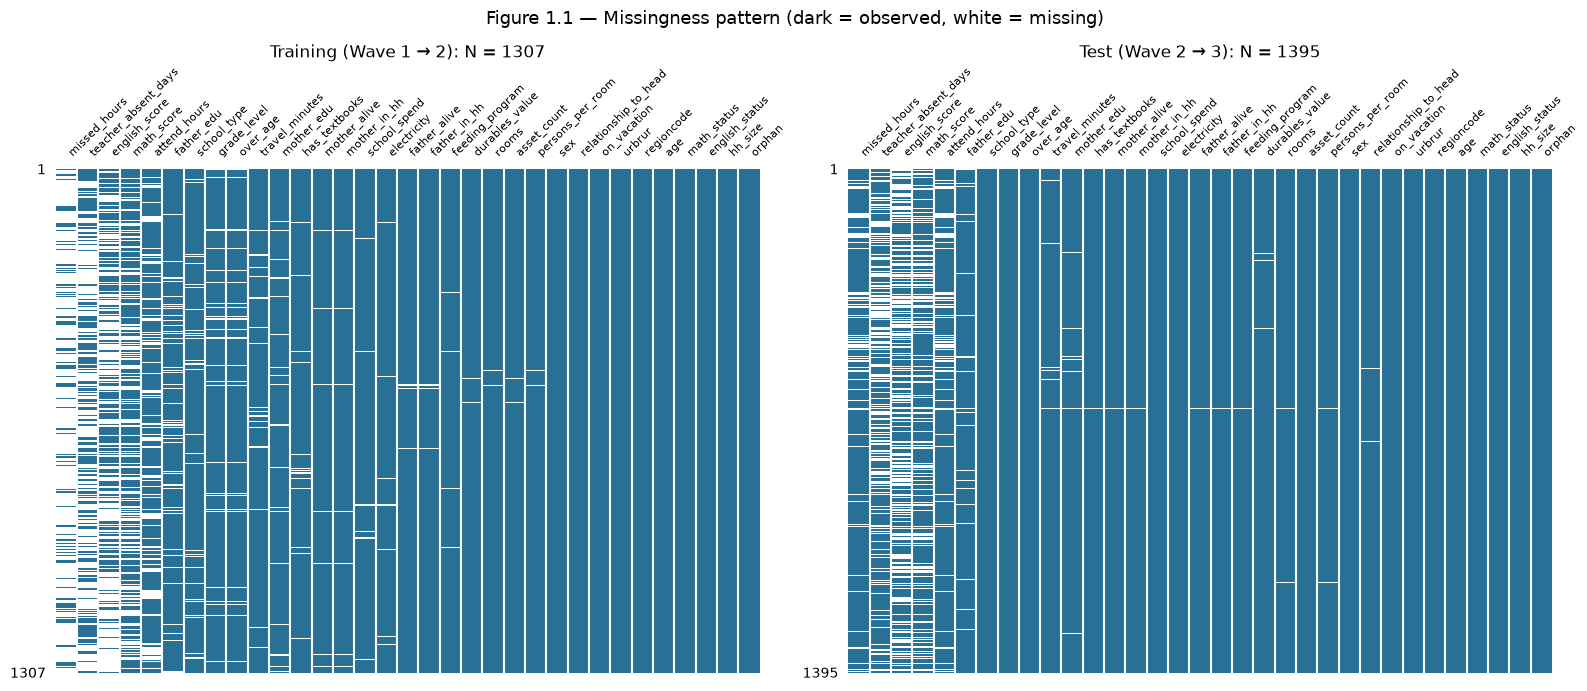

In [3]:
import matplotlib.pyplot as plt
import missingno as msno

def missing_table(df, name):
    m = df[FEATURES].isna()
    return pd.DataFrame({f"{name}: missing (n)": m.sum(), f"{name}: missing (%)": (m.mean() * 100).round(1)})

miss = pd.concat([missing_table(train, "Train"), missing_table(test, "Test")], axis=1)
miss = miss.sort_values("Train: missing (%)", ascending=False)
print("(a) Missing values per feature (features with no missing values not shown):")
print(miss[(miss["Train: missing (n)"] > 0) | (miss["Test: missing (n)"] > 0)].to_string())

for name, df in [("Train", train), ("Test", test)]:
    m = df[FEATURES].isna()
    complete = (~m.any(axis=1)).sum()
    print(f"\n{name}:")
    print(f"  (b) Overall missing: {m.values.sum()} of {m.size} feature cells = {m.values.mean() * 100:.2f}%")
    print(f"  (c) Complete rows: {complete} ({complete / len(df) * 100:.1f}%) | rows with >= 1 missing: {len(df) - complete} ({(len(df) - complete) / len(df) * 100:.1f}%)")
    print(f"      Features with no missing values: {(m.sum() == 0).sum()} of {len(FEATURES)}")

miss.to_csv(ROOT / "phase1_strategy" / "A3_missingness.csv")

# Figure 1.1: missingness matrix (white = missing), features ordered from most to least missing
order = miss.index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (name, df) in zip(axes, [("Training (Wave 1 → 2)", train), ("Test (Wave 2 → 3)", test)]):
    msno.matrix(df[order], ax=ax, sparkline=False, fontsize=8, color=(0.16, 0.44, 0.59))
    ax.set_title(f"{name}: N = {len(df)}", fontsize=12)
plt.suptitle("Figure 1.1 — Missingness pattern (dark = observed, white = missing)", fontsize=13)
plt.tight_layout()
plt.savefig(FIG / "fig1_1_missingness_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## A4. Target label (Y): binary classification
`dropout` = 1 if the child is out of school at the next wave without having completed basic education (JSS3), 0 if still enrolled. Figure 1.2 shows the class balance.

                Table  Enrolled (Y=0)  Dropout (Y=1)  Dropout rate (%) Imbalance ratio (0:1)  Class weight for Y=1 (n0/n1)
Training (Wave 1 → 2)            1119            188              14.4              5.95 : 1                          5.95
    Test (Wave 2 → 3)            1250            145              10.4              8.62 : 1                          8.62


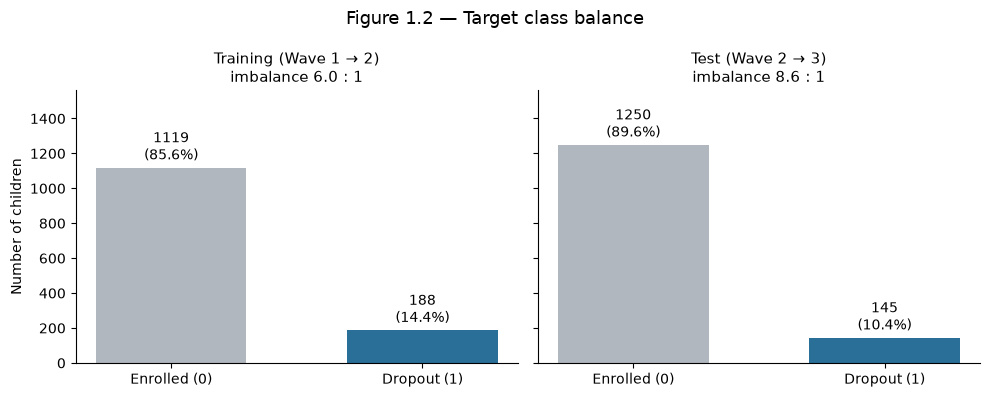

In [4]:
rows = []
for name, df in [("Training (Wave 1 → 2)", train), ("Test (Wave 2 → 3)", test)]:
    n1 = int(df[TARGET].sum()); n0 = len(df) - n1
    rows.append({"Table": name, "Enrolled (Y=0)": n0, "Dropout (Y=1)": n1,
                 "Dropout rate (%)": round(n1 / len(df) * 100, 1),
                 "Imbalance ratio (0:1)": f"{n0 / n1:.2f} : 1",
                 "Class weight for Y=1 (n0/n1)": round(n0 / n1, 2)})
target_summary = pd.DataFrame(rows)
print(target_summary.to_string(index=False))
target_summary.to_csv(ROOT / "phase1_strategy" / "A4_target.csv", index=False)

# Figure 1.2: class balance bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (name, df) in zip(axes, [("Training (Wave 1 → 2)", train), ("Test (Wave 2 → 3)", test)]):
    counts = df[TARGET].value_counts().reindex([0, 1])
    bars = ax.bar(["Enrolled (0)", "Dropout (1)"], counts.values, color=["#b0b7bf", "#2a6f97"], width=0.6)
    for b, v in zip(bars, counts.values):
        ax.text(b.get_x() + b.get_width() / 2, v + 20, f"{v}\n({v / len(df) * 100:.1f}%)", ha="center", va="bottom", fontsize=10)
    ax.set_title(f"{name}\nimbalance {counts[0] / counts[1]:.1f} : 1", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Number of children")
axes[0].set_ylim(0, max(len(train), len(test)) * 1.12)
plt.suptitle("Figure 1.2 — Target class balance", fontsize=13)
plt.tight_layout()
plt.savefig(FIG / "fig1_2_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## B1. Missingness mechanisms
### B1.1 Evidence: what is missingness related to?
For each feature with missing values (training table): dropout rate when missing vs observed (χ² test), and whether missingness differs by age, sex, urban/rural, northern regions, asset count and mother's presence (Mann-Whitney / χ², p < 0.05). Skewness of the observed values guides the imputation choice in B1.2.

In [5]:
from scipy import stats

COVARIATES = {"age": "num", "sex": "cat", "urbrur": "cat", "north": "cat", "asset_count": "num", "mother_in_hh": "cat"}
tr = train.assign(north=train["regioncode"].isin([8, 9, 10]).astype(int))   # Northern, Upper East, Upper West

def p_value(miss, x, kind):
    ok = x.notna()
    miss, x = miss[ok], x[ok]
    if miss.sum() < 5 or (~miss).sum() < 5:
        return np.nan
    if kind == "num":
        return stats.mannwhitneyu(x[miss], x[~miss]).pvalue
    return stats.chi2_contingency(pd.crosstab(miss, x))[1]

rows = []
for c in FEATURES:
    miss = tr[c].isna()
    if miss.sum() == 0:
        continue
    row = {"feature": c, "missing %": round(miss.mean() * 100, 1),
           "dropout | missing": round(tr.loc[miss, TARGET].mean(), 3),
           "dropout | observed": round(tr.loc[~miss, TARGET].mean(), 3),
           "p (missing vs Y)": p_value(miss, tr[TARGET], "cat")}
    related = []
    for cov, kind in COVARIATES.items():
        if cov == c:
            continue
        p = p_value(miss, tr[cov], kind)
        if p < 0.05:
            diff = tr.loc[miss, cov].mean() - tr.loc[~miss, cov].mean()
            related.append(f"{cov}({'+' if diff > 0 else '-'})")
    row["missingness related to (p<0.05)"] = ", ".join(related) if related else "none"
    if pd.api.types.is_numeric_dtype(tr[c]):
        row["skewness (observed)"] = round(tr[c].skew(), 2)
    rows.append(row)

b1_evidence = pd.DataFrame(rows).sort_values("missing %", ascending=False)
b1_evidence["p (missing vs Y)"] = b1_evidence["p (missing vs Y)"].map(lambda p: "n<5" if pd.isna(p) else f"{p:.3f}")
print(b1_evidence.to_string(index=False))
b1_evidence.to_csv(ROOT / "phase1_strategy" / "B1_missingness_evidence.csv", index=False)
print("\n(+) = higher among children with the value missing; (-) = lower. north = Northern/Upper East/Upper West regions.")

            feature  missing %  dropout | missing  dropout | observed p (missing vs Y)                      missingness related to (p<0.05)  skewness (observed)
       missed_hours       77.8              0.142               0.152            0.735                            north(-), mother_in_hh(-)                 1.93
teacher_absent_days       56.8              0.172               0.106            0.001          age(+), urbrur(-), north(+), asset_count(+)                 2.95
      english_score       54.8              0.155               0.130            0.234          age(-), urbrur(+), north(+), asset_count(-)                -0.32
         math_score       33.4              0.160               0.136            0.267                                     age(-), north(+)                -0.14
       attend_hours       21.8              0.168               0.137            0.214                                             north(+)                -0.96
         father_edu        7.7    

### B1.2 Mechanism diagnosis and imputation plan
Rules: numeric |skew| < 0.5 → mean; |skew| ≥ 0.5 → median; binary/ordinal → mode; nominal with informative missingness → "missing" category; indicator flag when missingness is structural, MNAR or related to Y. KNN (k=5) for grade level. All imputers are fitted on X_train only, inside each CV fold (Phase 2 pipeline). Listwise deletion is rejected: only 4.1% of rows are complete.

In [6]:
# Decision rules (applied consistently):
#   numeric, |skewness| < 0.5  -> mean   (near-symmetric: mean is unbiased and efficient)
#   numeric, |skewness| >= 0.5 -> median (robust to the long tail)
#   binary / ordinal           -> mode   (keeps a valid category)
#   nominal with informative missingness -> explicit "missing" category
#   + missing-indicator flag when missingness is structural, MNAR, or related to Y (p < 0.05)
# Every imputer is fitted on X_train only (inside the Phase 2 pipeline, re-fitted in each CV fold).
B1_DECISIONS = {
    "missed_hours": ("MAR (recording practice; varies by region). Blank = 0 hours missed",
        "Rule: 0 when attendance was recorded; remaining (vacation / attendance unknown) -> median",
        "W1 recorded >0 for 17.8% vs 14.4% in tablet-based W2; unrelated to Y (p=0.74); skew 1.93"),
    "teacher_absent_days": ("Structural (asked only if one main teacher) - informative",
        "Median (= 0) + indicator teacher_absent_missing",
        "Missingness predicts dropout (17.2% vs 10.6%, p=0.001); skew 2.95"),
    "english_score": ("MAR on age/region/wealth (not tested < 9 by design) + MNAR blank sheets",
        "Mean + keep english_status category (scored / blank_sheet / not_tested)",
        "Related to age, urban, north, assets; skew -0.32 -> mean; blank sheet = likely cannot read"),
    "math_score": ("MAR on age/region (not tested < 9 by design) + MNAR blank sheets",
        "Mean + keep math_status category",
        "Related to age, north; skew -0.14 -> mean; blank sheet dropout 36% vs 14%"),
    "attend_hours": ("Structural (school holiday) + MAR on region",
        "Median + on_vacation flag (already exists) + indicator attend_missing",
        "Related to north; skew -0.96 -> median"),
    "father_edu": ("MAR ('don't know' about an absent father)",
        "Mode + indicator father_edu_missing ('not reported', as in proposal)",
        "Related to urban, north, assets, mother presence; ordinal"),
    "school_type": ("MAR on region", "Constant category 'missing' (one-hot)",
        "Related to north; nominal; dropout 19.0% vs 14.1%"),
    "grade_level": ("MAR on region", "KNN (k=5) on age, sex, urban, region, asset_count",
        "Grade is strongly tied to age (rho 0.64) -> neighbours give a better estimate than one global value"),
    "over_age": ("MAR (missing exactly when grade is missing)", "Recomputed from the KNN-imputed grade",
        "over_age = age - grade_level - 5"),
    "travel_minutes": ("MAR on region / mother presence", "Median", "skew 3.15"),
    "mother_edu": ("MAR ('don't know' about an absent mother)", "Mode + indicator mother_edu_missing",
        "Related to urban, assets, mother presence; ordinal"),
    "has_textbooks": ("Consistent with MCAR", "Mode", "Unrelated to Y and covariates; ordinal"),
    "school_spend": ("MAR on age / urban / wealth", "Median", "skew 10.78"),
    "mother_in_hh": ("Consistent with MCAR", "Mode", "Binary; n missing = 20"),
    "mother_alive": ("Consistent with MCAR", "Mode", "Binary; n missing = 20"),
    "electricity": ("Possibly MAR (small n)", "Mode", "Binary; n missing = 17; p=0.034 but too few for an indicator"),
    "father_alive": ("MAR on urban / mother presence", "Mode", "Binary; n missing = 14"),
    "father_in_hh": ("MAR on urban / mother presence", "Mode", "Binary; n missing = 14"),
    "feeding_program": ("Consistent with MCAR", "Mode", "Binary; n missing = 11"),
    "asset_count": ("Consistent with MCAR", "Median", "skew 0.62"),
    "durables_value": ("Consistent with MCAR", "Median", "skew 10.05"),
    "rooms": ("Consistent with MCAR (household file not matched)", "Median", "skew 4.82"),
    "persons_per_room": ("Consistent with MCAR", "Recomputed from imputed rooms", "hh_size / rooms"),
    "relationship_to_head": ("Invalid code set to missing (test only, n=3)", "Mode", "Nominal"),
}
b1_plan = (b1_evidence.set_index("feature")[["missing %", "p (missing vs Y)", "skewness (observed)"]]
           .join(pd.DataFrame.from_dict(B1_DECISIONS, orient="index",
                                        columns=["Mechanism", "Treatment", "Evidence / justification"]), how="outer"))
b1_plan["missing %"] = b1_plan["missing %"].fillna(0.0)   # relationship_to_head: missing only in test
b1_plan = b1_plan.sort_values("missing %", ascending=False)
print(b1_plan[["missing %", "Mechanism", "Treatment"]].to_string())
b1_plan.to_csv(ROOT / "phase1_strategy" / "B1_mechanism_and_imputation_plan.csv")

                      missing %                                                                Mechanism                                                                                  Treatment
feature                                                                                                                                                                                            
missed_hours               77.8       MAR (recording practice; varies by region). Blank = 0 hours missed  Rule: 0 when attendance was recorded; remaining (vacation / attendance unknown) -> median
teacher_absent_days        56.8                Structural (asked only if one main teacher) - informative                                            Median (= 0) + indicator teacher_absent_missing
english_score              54.8  MAR on age/region/wealth (not tested < 9 by design) + MNAR blank sheets                    Mean + keep english_status category (scored / blank_sheet / not_tested)
math_score          

## B2. Outlier identification
### B2.1 Screening every numeric feature
Skewness and a normality test decide the rule: IQR (1.5 × IQR) for skewed / non-normal features, Z-score (|Z| > 3) only for approximately normal ones. Fences are computed on the training table only. The last column shows how many values IQR flags after a log1p transform.

In [7]:
NUMERIC = [c for c, (t, _) in VAR_TYPES.items() if t in ("Continuous", "Discrete")]
rows = []
for c in NUMERIC:
    x = train[c].dropna()
    q1, q3 = x.quantile([0.25, 0.75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    z_hi = x.mean() + 3 * x.std(); z_lo = x.mean() - 3 * x.std()
    lx = np.log1p(x.clip(lower=0))
    lq1, lq3 = lx.quantile([0.25, 0.75]); liqr = lq3 - lq1
    rows.append({
        "feature": c, "type": VAR_TYPES[c][0], "skew": round(x.skew(), 2),
        "normality p (D'Agostino)": f"{stats.normaltest(x).pvalue:.1e}",
        "share of zeros %": round((x == 0).mean() * 100, 1),
        "min": x.min(), "Q1": q1, "median": x.median(), "Q3": q3, "max": x.max(),
        "IQR fences": f"[{lo:.1f}, {hi:.1f}]",
        "IQR flagged (train)": int(((x < lo) | (x > hi)).sum()),
        "IQR flagged (test)": int(((test[c] < lo) | (test[c] > hi)).sum()),
        "|Z|>3 flagged (train)": int(((x < z_lo) | (x > z_hi)).sum()),
        "IQR flagged after log1p (train)": int(((lx < lq1 - 1.5 * liqr) | (lx > lq3 + 1.5 * liqr)).sum()),
    })
b2 = pd.DataFrame(rows)
pd.set_option("display.width", 250)
print(b2.to_string(index=False))
b2.to_csv(ROOT / "phase1_strategy" / "B2_outlier_screening.csv", index=False)

            feature       type  skew normality p (D'Agostino)  share of zeros %       min     Q1  median      Q3     max        IQR fences  IQR flagged (train)  IQR flagged (test)  |Z|>3 flagged (train)  IQR flagged after log1p (train)
       attend_hours Continuous -0.96                  1.1e-26               0.3  0.000000  25.00    30.0   35.00    50.0      [10.0, 50.0]                  132                  81                      0                              145
       missed_hours Continuous  1.93                  6.5e-25              37.2  0.000000   0.00     3.0    7.00    49.0     [-10.5, 17.5]                   38                  40                      5                                0
     travel_minutes Continuous  3.15                 5.8e-195               0.2  0.000000  10.00    20.0   40.00   300.0     [-35.0, 85.0]                   77                  92                     13                                5
       school_spend Continuous 10.78                  0.

## B3. Outlier treatment: capping (Winsorizing), not deletion
Upper-tail capping at IQR fences computed on log1p(x) of the training data and converted back to original units. Rows are never deleted. Exempt: attendance (low values are the risk signal), zero-inflated teacher absence, bounded scales. Bounds are fitted on X_train only and applied unchanged to the test set (Phase 2: inside the pipeline, per CV fold).

            feature                   treatment  upper bound (train)  capped (train)  capped (test) train max before -> after
     travel_minutes log1p + IQR cap (Winsorize)                294.0             2.0            0.0              300 -> 294.0
       school_spend log1p + IQR cap (Winsorize)               3120.2             1.0            1.0            6500 -> 3120.2
     durables_value log1p + IQR cap (Winsorize)              17123.4             9.0           74.0          63791 -> 17123.4
              rooms log1p + IQR cap (Winsorize)                 18.8             5.0            1.0                52 -> 18.8
            hh_size log1p + IQR cap (Winsorize)                 15.2             6.0            4.0                20 -> 15.2
   persons_per_room        log1p, no cap needed                  NaN             NaN            NaN                       NaN
       missed_hours        log1p, no cap needed                  NaN             NaN            NaN                   

C:\Users\emuhi\AppData\Local\Temp\ipykernel_18556\3931689190.py:47: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=True, widths=0.5, patch_artist=True,
C:\Users\emuhi\AppData\Local\Temp\ipykernel_18556\3931689190.py:47: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=True, widths=0.5, patch_artist=True,
C:\Users\emuhi\AppData\Local\Temp\ipykernel_18556\3931689190.py:47: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=True, widths=0.5, patch_artist=True,
C:\Users\emuhi\AppData\Local\Temp\ipykernel_18556\3931689190.py:47: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11

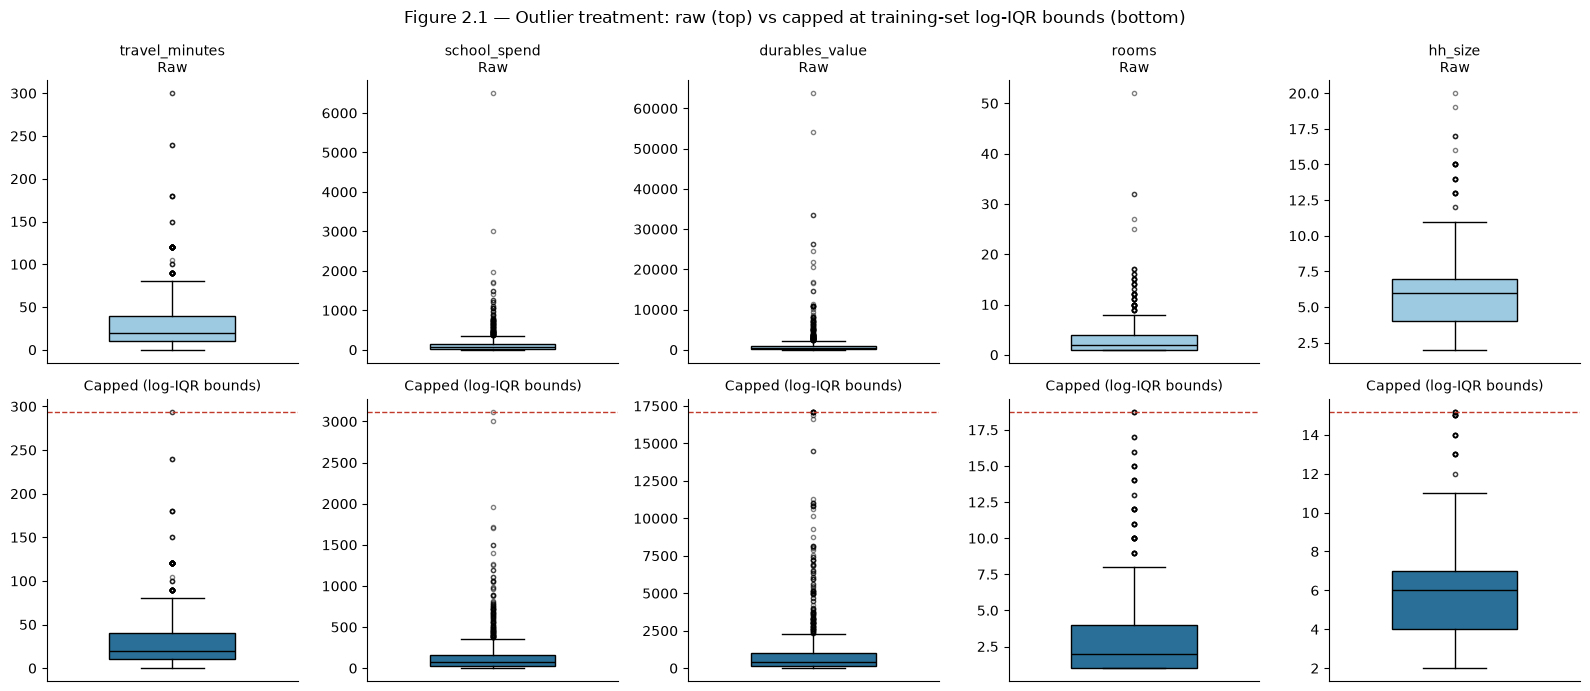

In [8]:
# Outlier treatment plan. Capping bounds = IQR fences computed on log1p(x) of the TRAINING data,
# converted back to original units. Only the UPPER tail is capped: low values (0 cedis spent, 0 minutes'
# travel for a boarder) are genuine. Nothing is deleted: values above the bound are set to the bound.
B3_PLAN = {
    "travel_minutes":   ("log1p + IQR cap (Winsorize)", "Right-skewed (3.15); raw IQR would cap 77 plausible long walks"),
    "school_spend":     ("log1p + IQR cap (Winsorize)", "Extreme right skew (10.8); money variable"),
    "durables_value":   ("log1p + IQR cap (Winsorize)", "Extreme right skew (10.1); money variable"),
    "rooms":            ("log1p + IQR cap (Winsorize)", "Compound houses up to 52 rooms"),
    "hh_size":          ("log1p + IQR cap (Winsorize)", "Very large households (up to 20)"),
    "persons_per_room": ("log1p, no cap needed", "0 values flagged after log1p"),
    "missed_hours":     ("log1p, no cap needed", "0 flagged after log1p; high absence is the key risk signal"),
    "attend_hours":     ("No capping", "Low attendance (<10 h) is the dropout signal; impossible values already removed (>50 h)"),
    "teacher_absent_days": ("No capping", "Zero-inflated (75% zeros): IQR degenerates; bounded 0-22 by plausibility rule"),
    "age":              ("No capping", "Bounded scale 8-13 by design"),
    "over_age":         ("No capping", "Valid range -3 to 7; derived from age and grade"),
    "math_score":       ("No capping", "Bounded test scale 0-8"),
    "english_score":    ("No capping", "Bounded test scale 0-7"),
    "asset_count":      ("No capping", "Bounded count 0-10"),
}
CAP = [c for c, (t, _) in B3_PLAN.items() if t.startswith("log1p + IQR cap")]

bounds, rows = {}, []
for c in B3_PLAN:
    x = train[c].dropna()
    row = {"feature": c, "treatment": B3_PLAN[c][0], "reason": B3_PLAN[c][1]}
    if c in CAP:
        lx = np.log1p(x)
        lq1, lq3 = lx.quantile([0.25, 0.75]); liqr = lq3 - lq1
        hi = np.expm1(lq3 + 1.5 * liqr)
        bounds[c] = hi
        row.update({"upper bound (train)": round(hi, 1),
                    "capped (train)": int((x > hi).sum()),
                    "capped (test)": int((test[c] > hi).sum()),
                    "train max before -> after": f"{x.max():g} -> {min(x.max(), hi):.1f}"})
    rows.append(row)
b3 = pd.DataFrame(rows)
print(b3.drop(columns="reason").to_string(index=False))
b3.to_csv(ROOT / "phase1_strategy" / "B3_outlier_treatment_plan.csv", index=False)

# Figure 2.1: raw vs capped, side by side
fig, axes = plt.subplots(2, len(CAP), figsize=(3.2 * len(CAP), 7))
for j, c in enumerate(CAP):
    raw = train[c].dropna()
    capped = raw.clip(upper=bounds[c])
    for i, (data, label) in enumerate([(raw, "Raw"), (capped, "Capped (log-IQR bounds)")]):
        ax = axes[i, j]
        ax.boxplot(data, vert=True, widths=0.5, patch_artist=True,
                   boxprops=dict(facecolor="#9ecae1" if i == 0 else "#2a6f97"),
                   medianprops=dict(color="black"), flierprops=dict(marker="o", markersize=3, alpha=0.5))
        ax.set_xticks([])
        ax.set_title(f"{c}\n{label}" if i == 0 else label, fontsize=10)
        if i == 1:
            ax.axhline(bounds[c], color="#c0392b", ls="--", lw=1)
        ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("Figure 2.1 — Outlier treatment: raw (top) vs capped at training-set log-IQR bounds (bottom)", fontsize=12)
plt.tight_layout()
plt.savefig(FIG / "fig2_1_outlier_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()

## B4. Statistical association and multicollinearity
### B4a. Feature–target test matrix
Numeric/ordinal features vs binary Y: Mann-Whitney U (non-normal data, see B2) with rank-biserial r as effect size; point-biserial r reported for reference. Binary/nominal: χ² test with Cramér's V. Mutual information for every feature (captures non-linear association) ranks the features in Figure 3.3. Computed on the training table only.

             feature       type                              test             statistic  p-value              effect size  mutual information significant (p<0.05)
          regioncode    Nominal                        Chi-square      chi2=113.7, df=9 2.61e-20      Cramér's V = +0.295              0.0367                  yes
      durables_value Continuous Mann-Whitney U (+ point-biserial) U=111114; r_pb=-0.017 1.49e-01 rank-biserial r = +0.066              0.0213                   no
               rooms   Discrete Mann-Whitney U (+ point-biserial) U=122046; r_pb=+0.067 2.00e-04 rank-biserial r = +0.165              0.0177                  yes
        school_spend Continuous Mann-Whitney U (+ point-biserial)  U=80782; r_pb=-0.046 1.39e-05 rank-biserial r = -0.200              0.0133                  yes
       english_score   Discrete Mann-Whitney U (+ point-biserial)  U=14936; r_pb=-0.144 4.34e-04 rank-biserial r = -0.245              0.0125                  yes
             hh_size  

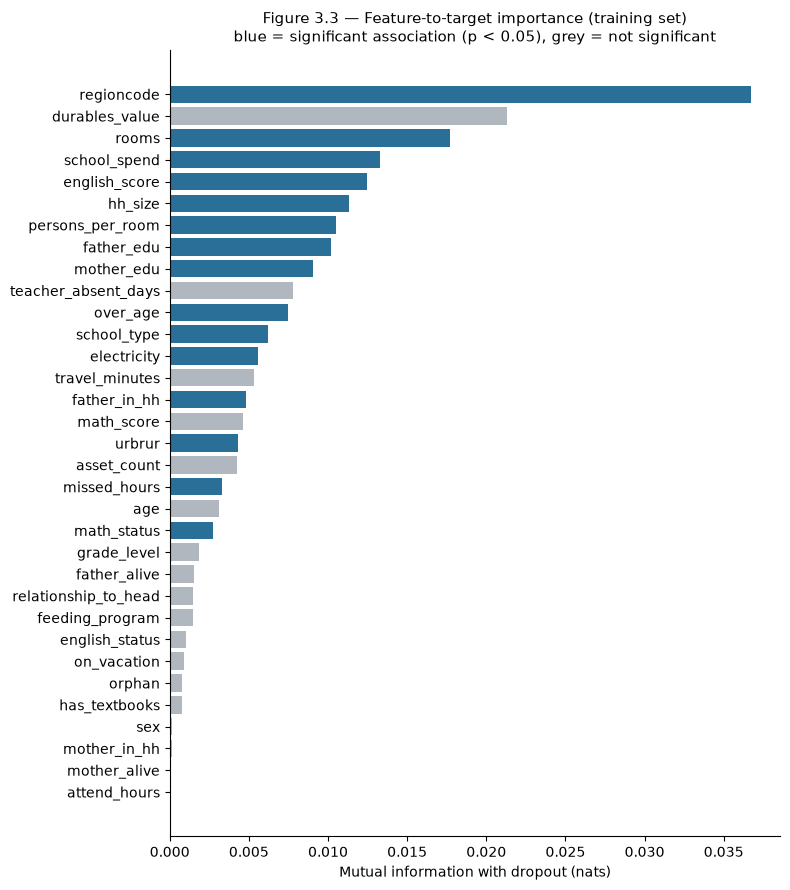

In [9]:
from sklearn.feature_selection import mutual_info_classif

def cramers_v(table):
    chi2 = stats.chi2_contingency(table)[0]
    n = table.values.sum(); r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

rows = []
for c in FEATURES:
    t = VAR_TYPES[c][0]
    d = train[[c, TARGET]].dropna()
    x, y = d[c], d[TARGET]
    if t in ("Continuous", "Discrete", "Ordinal"):
        # Non-normal (B2) -> rank-based Mann-Whitney U; effect size = rank-biserial r. Point-biserial r reported for reference.
        u = stats.mannwhitneyu(x[y == 1], x[y == 0])
        rbc = 2 * u.statistic / ((y == 1).sum() * (y == 0).sum()) - 1
        rpb = stats.pointbiserialr(y, x)[0]
        test_name, stat, p, effect = "Mann-Whitney U (+ point-biserial)", f"U={u.statistic:.0f}; r_pb={rpb:+.3f}", u.pvalue, ("rank-biserial r", rbc)
        x_mi = x.values.reshape(-1, 1); discrete = t != "Continuous"
    else:  # Binary / Nominal
        tab = pd.crosstab(x, y)
        chi2, p, dof, _ = stats.chi2_contingency(tab)
        test_name, stat, effect = "Chi-square", f"chi2={chi2:.1f}, df={dof}", ("Cramér's V", cramers_v(tab))
        x_mi = pd.factorize(x)[0].reshape(-1, 1); discrete = True
    mi = mutual_info_classif(x_mi, y, discrete_features=[discrete], random_state=42)[0]
    rows.append({"feature": c, "type": t, "test": test_name, "statistic": stat, "p-value": p,
                 "effect size": f"{effect[0]} = {effect[1]:+.3f}", "|effect|": abs(effect[1]),
                 "mutual information": mi})

b4a = pd.DataFrame(rows)
b4a["significant (p<0.05)"] = np.where(b4a["p-value"] < 0.05, "yes", "no")
b4a = b4a.sort_values("mutual information", ascending=False)
show = b4a.copy(); show["p-value"] = show["p-value"].map(lambda p: f"{p:.2e}"); show["mutual information"] = show["mutual information"].round(4)
print(show[["feature", "type", "test", "statistic", "p-value", "effect size", "mutual information", "significant (p<0.05)"]].to_string(index=False))
b4a.to_csv(ROOT / "phase1_strategy" / "B4a_feature_target_tests.csv", index=False)

# Figure 3.3: feature-to-target importance (mutual information), significant features highlighted
fig, ax = plt.subplots(figsize=(8, 9))
s = b4a.sort_values("mutual information")
ax.barh(s["feature"], s["mutual information"],
        color=np.where(s["significant (p<0.05)"] == "yes", "#2a6f97", "#b0b7bf"))
ax.set_xlabel("Mutual information with dropout (nats)")
ax.set_title("Figure 3.3 — Feature-to-target importance (training set)\nblue = significant association (p < 0.05), grey = not significant", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIG / "fig3_3_target_importance.png", dpi=300, bbox_inches="tight")
plt.show()

### B4b. Multicollinearity protocol
Spearman ρ (non-normal data). Flag pairs with |ρ| ≥ 0.85 and features with VIF > 10 (VIF on median-imputed, standardised training data). Decision rule: keep the feature with higher mutual information with Y (B4a); if close, keep the directly measured variable over the derived one. Re-check VIF after removal.

Pairs with |Spearman rho| >= 0.85:
  father_alive – orphan: rho = -0.850
  rooms – persons_per_room: rho = -0.855

VIF before removal (top 6):
orphan          20.2
grade_level     19.9
age             17.0
father_alive    14.4
over_age        14.1
mother_alive     5.9

VIF after removing ['persons_per_room', 'orphan', 'grade_level'] (top 6):
asset_count     1.9
father_in_hh    1.8
electricity     1.6
urbrur          1.6
mother_edu      1.6
father_edu      1.6

Max VIF after removal: 1.89


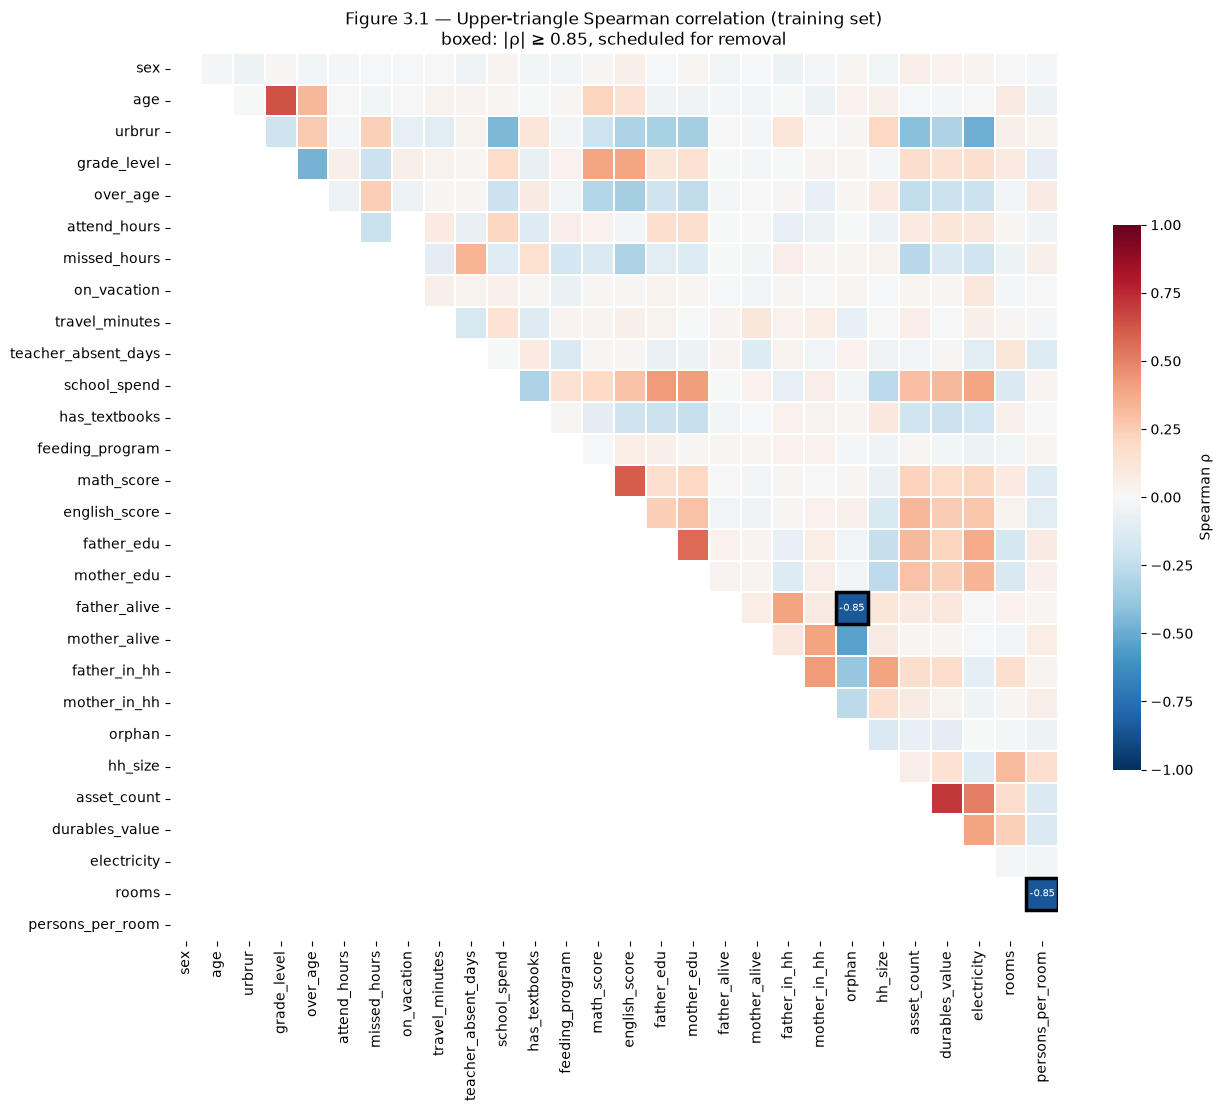

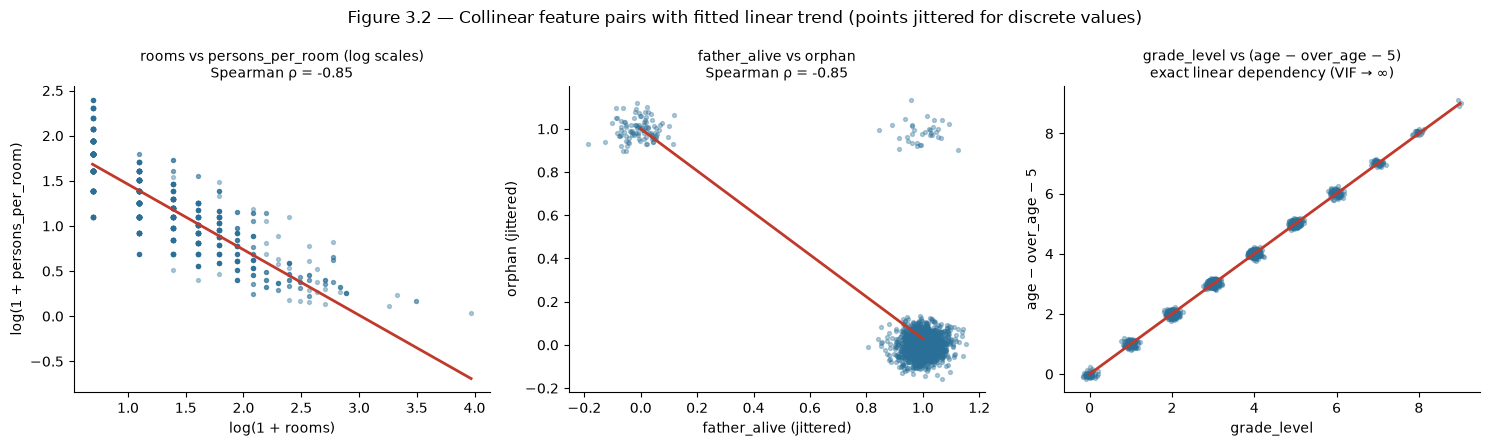

In [10]:
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Numeric, ordinal and binary features (multi-level nominal features are excluded from correlation/VIF)
CORR_FEATS = [c for c in FEATURES if VAR_TYPES[c][0] in ("Continuous", "Discrete", "Ordinal", "Binary")]
rho = train[CORR_FEATS].corr(method="spearman")      # Spearman: data are non-normal (B2)

# (1) Pairwise screen: |rho| >= 0.85
pairs = [(a, b, rho.loc[a, b]) for i, a in enumerate(CORR_FEATS) for b in CORR_FEATS[i + 1:] if abs(rho.loc[a, b]) >= 0.85]
print("Pairs with |Spearman rho| >= 0.85:")
for a, b, r in pairs:
    print(f"  {a} – {b}: rho = {r:+.3f}")

# (2) VIF > 10 (median-imputed, standardised; VIF on training data only)
def vif_table(cols):
    X = train[cols].fillna(train[cols].median())
    X = (X - X.mean()) / X.std()
    X.insert(0, "const", 1.0)
    return pd.Series([variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])], index=cols).sort_values(ascending=False)

vif_before = vif_table(CORR_FEATS)
print("\nVIF before removal (top 6):"); print(vif_before.head(6).round(1).to_string())

# (3) Decision rule: in each collinear pair/group, keep the feature with the higher mutual information with Y (B4a);
#     if close, keep the directly measured variable over the derived one.
mi = b4a.set_index("feature")["mutual information"]
DROP = {
    "persons_per_room": "rho = -0.86 with rooms; derived (hh_size / rooms); lower MI (0.0105 vs 0.0177)",
    "orphan":           "|r| = 0.85 with father_alive; derived from father/mother_alive; VIF 20; lower MI (0.0008 vs 0.0015)",
    "grade_level":      "Exact linear dependency: over_age = age - grade_level - 5 (VIF -> infinity); lowest MI of the three (0.0019)",
}
vif_after = vif_table([c for c in CORR_FEATS if c not in DROP])
print("\nVIF after removing", list(DROP), "(top 6):"); print(vif_after.head(6).round(1).to_string())
print("\nMax VIF after removal:", round(vif_after.max(), 2))
pd.DataFrame({"reason": DROP}).to_csv(ROOT / "phase1_strategy" / "B4b_multicollinearity_drops.csv")
pd.DataFrame({"VIF before": vif_before, "VIF after": vif_after}).round(2).to_csv(ROOT / "phase1_strategy" / "B4b_vif.csv")

# Figure 3.1: upper-triangle Spearman heatmap, collinear pairs outlined
mask = np.tril(np.ones_like(rho, dtype=bool))
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(rho, mask=mask, cmap="RdBu_r", vmin=-1, vmax=1, center=0, square=True, linewidths=0.3,
            cbar_kws={"shrink": 0.6, "label": "Spearman ρ"}, ax=ax)
for a, b, r in pairs:
    i, j = CORR_FEATS.index(a), CORR_FEATS.index(b)
    ax.add_patch(plt.Rectangle((max(i, j), min(i, j)), 1, 1, fill=False, edgecolor="black", lw=2.5))
    ax.text(max(i, j) + 0.5, min(i, j) + 0.5, f"{r:.2f}", ha="center", va="center", fontsize=7, color="white")
ax.set_title("Figure 3.1 — Upper-triangle Spearman correlation (training set)\nboxed: |ρ| ≥ 0.85, scheduled for removal", fontsize=12)
plt.tight_layout()
plt.savefig(FIG / "fig3_1_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 3.2: collinear pairs with fitted linear trend lines
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
rng = np.random.default_rng(0)

# (a) rooms vs persons_per_room: inverse relationship -> plotted and fitted on log scales
d = train[["rooms", "persons_per_room"]].dropna()
lx, ly = np.log1p(d["rooms"]), np.log1p(d["persons_per_room"])
axes[0].scatter(lx, ly, s=8, alpha=0.35, color="#2a6f97")
b1_, b0_ = np.polyfit(lx, ly, 1); xs = np.linspace(lx.min(), lx.max(), 50)
axes[0].plot(xs, b0_ + b1_ * xs, color="#c0392b", lw=2)
axes[0].set_xlabel("log(1 + rooms)"); axes[0].set_ylabel("log(1 + persons_per_room)")
axes[0].set_title(f"rooms vs persons_per_room (log scales)\nSpearman ρ = {d['rooms'].corr(d['persons_per_room'], method='spearman'):+.2f}", fontsize=10)

# (b) father_alive vs orphan: both binary -> jittered points
d = train[["father_alive", "orphan"]].dropna()
axes[1].scatter(d["father_alive"] + rng.normal(0, 0.05, len(d)), d["orphan"] + rng.normal(0, 0.05, len(d)), s=8, alpha=0.35, color="#2a6f97")
b1_, b0_ = np.polyfit(d["father_alive"], d["orphan"], 1); xs = np.linspace(0, 1, 50)
axes[1].plot(xs, b0_ + b1_ * xs, color="#c0392b", lw=2)
axes[1].set_xlabel("father_alive (jittered)"); axes[1].set_ylabel("orphan (jittered)")
axes[1].set_title(f"father_alive vs orphan\nSpearman ρ = {d['father_alive'].corr(d['orphan'], method='spearman'):+.2f}", fontsize=10)

# (c) exact dependency: grade_level equals age - over_age - 5 for every child
d = train[["grade_level", "age", "over_age"]].dropna()
implied = d["age"] - d["over_age"] - 5
axes[2].scatter(d["grade_level"] + rng.normal(0, 0.08, len(d)), implied + rng.normal(0, 0.08, len(d)), s=8, alpha=0.35, color="#2a6f97")
axes[2].plot([0, 9], [0, 9], color="#c0392b", lw=2)
axes[2].set_xlabel("grade_level"); axes[2].set_ylabel("age − over_age − 5")
axes[2].set_title("grade_level vs (age − over_age − 5)\nexact linear dependency (VIF → ∞)", fontsize=10)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("Figure 3.2 — Collinear feature pairs with fitted linear trend (points jittered for discrete values)", fontsize=12)
plt.tight_layout()
plt.savefig(FIG / "fig3_2_collinear_scatterplots.png", dpi=300, bbox_inches="tight")
plt.show()

## C. Encoding, scaling and transformation
### C1. Encoding and scaling plan (30 features after B4b)
One-hot for low-cardinality nominal features; ordinal integers for ranked categories; 0/1 for binary. Money variables converted to within-wave percentile ranks to remove the inflation shift between 2009/10 and 2013/14. XGBoost: no scaling (scale-invariant). Logistic regression and PCA: log1p for skewed features, then StandardScaler (fitted on X_train only). Figure 4.1 shows the transformation stages.

                            Type                                                         Encoding                        Scaling: XGBoost Scaling: logistic regression / PCA
sex                       Binary                                                    0/1 indicator  None (tree splits are scale-invariant)                                  —
age                     Discrete                                            Numeric (no encoding)  None (tree splits are scale-invariant)                     StandardScaler
regioncode               Nominal                                        One-hot (low cardinality)  None (tree splits are scale-invariant)                                  —
urbrur                    Binary                                                    0/1 indicator  None (tree splits are scale-invariant)                                  —
relationship_to_head     Nominal  Collapse to 3 levels (own child / grandchild / other) → one-hot  None (tree splits are scale-invarian

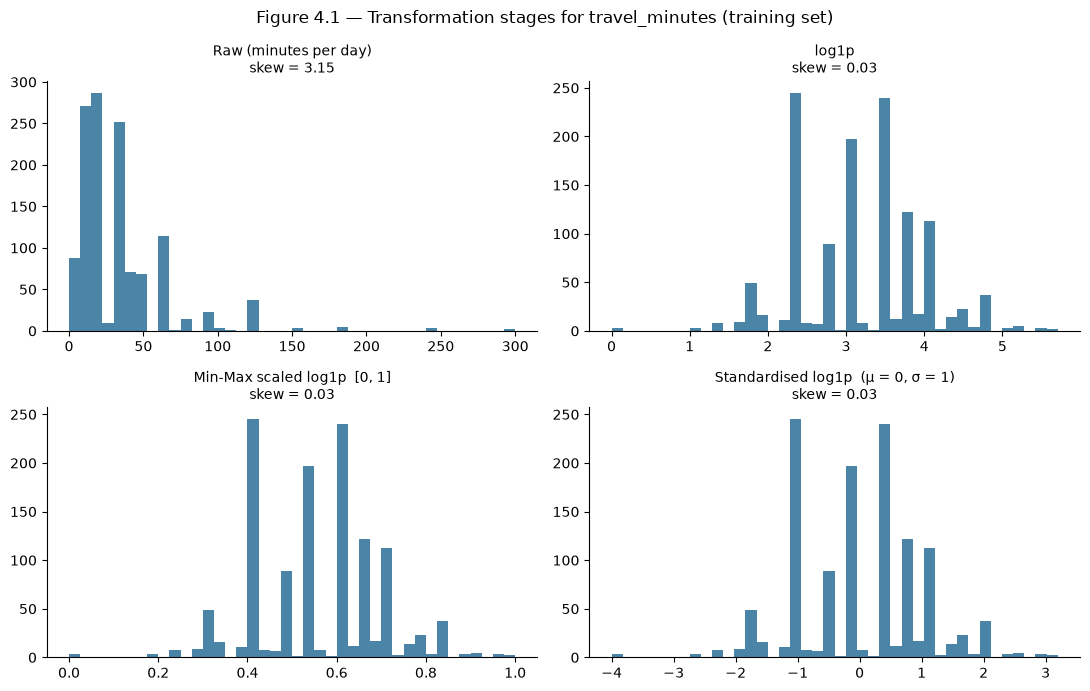

In [11]:
FINAL_FEATURES = [c for c in FEATURES if c not in DROP]          # 30 features after B4b
C1_PLAN = {}
for c in FINAL_FEATURES:
    t = VAR_TYPES[c][0]
    if t == "Nominal":
        enc = "One-hot (low cardinality)"
    elif t == "Binary":
        enc = "0/1 indicator"
    elif t == "Ordinal":
        enc = "Ordinal integers (0 = lowest)"
    else:
        enc = "Numeric (no encoding)"
    log = c in ["travel_minutes", "school_spend", "durables_value", "rooms", "hh_size", "missed_hours"]
    scale_lr = "—" if t in ("Nominal", "Binary") else ("log1p → StandardScaler" if log else "StandardScaler")
    C1_PLAN[c] = (t, enc, "None (tree splits are scale-invariant)", scale_lr)
C1_PLAN["relationship_to_head"] = ("Nominal", "Collapse to 3 levels (own child / grandchild / other) → one-hot", *C1_PLAN["relationship_to_head"][2:])
C1_PLAN["has_textbooks"] = ("Ordinal", "Re-map so higher = more books: none 0, some 1, all 2", *C1_PLAN["has_textbooks"][2:])
C1_PLAN["school_type"] = ("Nominal", "One-hot incl. 'missing' level (B1)", *C1_PLAN["school_type"][2:])
C1_PLAN["durables_value"] = ("Continuous", "Within-wave percentile rank (removes 2009→2013 inflation)", "None", "StandardScaler")
C1_PLAN["school_spend"] = ("Continuous", "Within-wave percentile rank (removes inflation)", "None", "StandardScaler")

c1 = pd.DataFrame.from_dict(C1_PLAN, orient="index", columns=["Type", "Encoding", "Scaling: XGBoost", "Scaling: logistic regression / PCA"])
print(c1.to_string())
c1.to_csv(ROOT / "phase1_strategy" / "C1_encoding_scaling_plan.csv")

# Width of the model matrix after encoding (+ 4 missing indicators from B1)
nominal_levels = {"regioncode": train["regioncode"].nunique(), "school_type": 5, "relationship_to_head": 3,
                  "math_status": 3, "english_status": 3}
n_other = len([c for c in FINAL_FEATURES if c not in nominal_levels])
print(f"\nEncoded width: {n_other} numeric/ordinal/binary + {sum(nominal_levels.values())} one-hot columns "
      f"+ 4 missing indicators = {n_other + sum(nominal_levels.values()) + 4} columns "
      f"(logistic regression drops one level per nominal feature: {n_other + sum(nominal_levels.values()) - len(nominal_levels) + 4})")

# Why within-wave ranks for money: the same percentile means the same relative position in each wave
for c in ["durables_value", "school_spend"]:
    print(f"{c}: median train {train[c].median():.0f} vs test {test[c].median():.0f} cedis "
          f"(ratio {test[c].median() / train[c].median():.2f}); after within-wave ranking both medians = 0.50")

# Figure 4.1: Raw -> Log -> Min-Max -> Standardised (travel_minutes, training set)
from sklearn.preprocessing import MinMaxScaler, StandardScaler
x = train["travel_minutes"].dropna().values.reshape(-1, 1)
stages = [("Raw (minutes per day)", x), ("log1p", np.log1p(x))]
stages += [("Min-Max scaled log1p  [0, 1]", MinMaxScaler().fit_transform(stages[1][1])),
           ("Standardised log1p  (μ = 0, σ = 1)", StandardScaler().fit_transform(stages[1][1]))]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (title, v) in zip(axes.ravel(), stages):
    v = v.ravel()
    ax.hist(v, bins=40, color="#2a6f97", alpha=0.85)
    ax.set_title(f"{title}\nskew = {pd.Series(v).skew():.2f}", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("Figure 4.1 — Transformation stages for travel_minutes (training set)", fontsize=12)
plt.tight_layout()
plt.savefig(FIG / "fig4_1_transformation_grid.png", dpi=300, bbox_inches="tight")
plt.show()

### C2. Split strategy and leakage prevention
Temporal hold-out: train on Wave 1 → 2, test once on Wave 2 → 3. Inside training: 5-fold StratifiedGroupKFold (stratified on dropout, grouped by district; households are nested in districts). All preprocessing (imputation, capping, encoding, scaling) lives inside a scikit-learn Pipeline and is re-fitted on the training part of each fold only.

In [12]:
from sklearn.model_selection import StratifiedGroupKFold

# (1) Nesting check: every household lies inside one district -> grouping by district also keeps households together
hh_in_one_district = train.groupby("FPrimary")["district_id"].nunique().max() == 1
print("Each household lies in exactly one district:", hh_in_one_district)

# (2) 5-fold cross-validation inside the training table, stratified on Y and grouped by district
X_tr, y_tr, groups = train[FINAL_FEATURES], train[TARGET], train["district_id"]
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for k, (tr_idx, va_idx) in enumerate(cv.split(X_tr, y_tr, groups), start=1):
    tr_d, va_d = set(groups.iloc[tr_idx]), set(groups.iloc[va_idx])
    tr_h, va_h = set(train["FPrimary"].iloc[tr_idx]), set(train["FPrimary"].iloc[va_idx])
    rows.append({"fold": k, "train rows": len(tr_idx), "validation rows": len(va_idx),
                 "validation %": round(len(va_idx) / len(train) * 100, 1),
                 "dropout % (train)": round(y_tr.iloc[tr_idx].mean() * 100, 1),
                 "dropout % (validation)": round(y_tr.iloc[va_idx].mean() * 100, 1),
                 "dropouts in validation": int(y_tr.iloc[va_idx].sum()),
                 "validation districts": len(va_d),
                 "shared districts": len(tr_d & va_d), "shared households": len(tr_h & va_h)})
folds = pd.DataFrame(rows)
print(folds.to_string(index=False))
folds.to_csv(ROOT / "phase1_strategy" / "C2_cv_folds.csv", index=False)

# (3) Temporal hold-out
labelled = len(train) + len(test)
both = set(zip(train["FPrimary"], train["hhmid"])) & set(zip(test["FPrimary"], test["hhmid"]))
print(f"\nTemporal split: train = Wave 1 → 2 ({len(train)} rows, {len(train) / labelled * 100:.0f}% of labelled children), "
      f"test = Wave 2 → 3 ({len(test)} rows, {len(test) / labelled * 100:.0f}%)")
print(f"Children present in both tables: {len(both)} (test results reported with and without them)")
print(f"Comparison: a random 70/15/15 split of the training table would leave about "
      f"{int(0.15 * y_tr.sum())} dropouts each in validation and test")

Each household lies in exactly one district: True
 fold  train rows  validation rows  validation %  dropout % (train)  dropout % (validation)  dropouts in validation  validation districts  shared districts  shared households
    1        1042              265          20.3               14.4                    14.3                      38                    24                 0                  0
    2        1055              252          19.3               14.6                    13.5                      34                    25                 0                  0
    3        1037              270          20.7               14.0                    15.9                      43                    30                 0                  0
    4        1050              257          19.7               14.7                    13.2                      34                    30                 0                  0
    5        1044              263          20.1               14.3        